# Churning prediction
In this project I will build a model to predict whether a customer will churn or not based on kaggle's telco customer churn dataset. I will explore the data, pre-process it and once transformed correctly build several models and compare them to each other. After finding the best model, evaluate its predictions and draw conclusions from a business perspective. The project is mainly implemented in pandas and sklearn.

# Imports and dataset loading

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_original = df.copy() #important for later (data export)

# Data exploration

In [2]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Most of our attributes are non-numeric but first let's deal with missing or invalid values.

In [4]:
nan_values_per_attribute = df.isna().sum()
print(nan_values_per_attribute)
total_nans = df.isna().sum().sum()
print(f"Number of nans in the entire dataframe: {total_nans}")

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Number of nans in the entire dataframe: 0


There are no invalid values. As for the non-numeric values, I will start with the attributes with the values "Yes" or "No". These can easily be converted into numbers using the built-in LabelEncoder.

In [5]:
attribute_names = list(df.columns)
yes_no_attributes = []
for name in attribute_names:
    if df[name].nunique() == 2 and str(df[name].dtype) not in ('int64', 'float64'):
        yes_no_attributes.append(name)
print(f"The list of said attributes: {yes_no_attributes}")

The list of said attributes: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


Before encoding these columns chosen above, I will review the rest of the features.

In [6]:
numeric_attributes = [x for x in attribute_names if str(df[x].dtype) == 'int64' or str(df[x].dtype) == 'float64']
remaining_attributes = [x for x in attribute_names if x not in yes_no_attributes and x not in numeric_attributes]
print(f"Already numeric attributes: {numeric_attributes}")
print(f"Remaining attributes: {remaining_attributes}")
for a in remaining_attributes:
    print(f"\nValue counts of attribute {a}:")
    print(df[a].value_counts())

Already numeric attributes: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Remaining attributes: ['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'TotalCharges']

Value counts of attribute customerID:
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

Value counts of attribute MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Value counts of attribute InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Value counts of attribute OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service   

Other than customerID and TotalCharges the attributes all have less than 5 possible values which makes them good options for one-hot encoding. The customerID columns is not useful for machine learning models so it will be dropped. As for TotalCharges it seemingly has numeric values represented in the object data type, so I will try a direct conversion.

However before encoding the dataset must be split to avoid data leakage.

# Splitting the dataset

In [7]:
target_df = df['Churn']
df = df.drop('Churn', axis=1)

X_train, X_test, y_train, y_test = train_test_split(df, target_df, test_size=0.25, random_state=42)

# Encoding and final dataframe assembly

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

df_train_preprocessed = pd.DataFrame(index=df_train.index) #index parameter given to avoid index misalignment later on
df_test_preprocessed = pd.DataFrame(index=df_test.index)

le = LabelEncoder()
for to_encode in yes_no_attributes:
    df_train_encoded = le.fit_transform(list(df_train[to_encode]))
    df_train_preprocessed[to_encode+'_encoded'] = df_train_encoded

    df_test_encoded = le.transform(list(df_test[to_encode]))
    df_test_preprocessed[to_encode+'_encoded'] = df_test_encoded

ohe = OneHotEncoder(sparse_output=False)
train_ohe, test_ohe = [], []
#to avoid highly fragmented dataframes, collect the encoded attributes as dataframes in list and concatenate after the loop
for to_encode in remaining_attributes[1:-1]:
    train_ohe.append(pd.DataFrame(ohe.fit_transform(df_train[[to_encode]]), columns=ohe.get_feature_names_out([to_encode]), index=df_train.index))
    test_ohe.append(pd.DataFrame(ohe.transform(df_test[[to_encode]]), columns=ohe.get_feature_names_out([to_encode]), index=df_test.index))

df_train_preprocessed = pd.concat([df_train_preprocessed] + train_ohe, axis=1)
df_test_preprocessed = pd.concat([df_test_preprocessed] + test_ohe, axis=1)

df_train_preprocessed[numeric_attributes] = df_train[numeric_attributes]
df_test_preprocessed[numeric_attributes] = df_test[numeric_attributes]

#df_train_preprocessed['TotalCharges'] = pd.to_numeric(df_train['TotalCharges'], errors='raise')

The commented line of code raised an error about there being an empty string in the TotalCharges column. First it will be replaced with a Nan value, then the rows of those NaN values will be dropped.

In [9]:
df_train_preprocessed['TotalCharges'] = pd.to_numeric(df_train['TotalCharges'], errors='coerce')
print(df_train_preprocessed.isna().sum().sum())
df_train_preprocessed = df_train_preprocessed.dropna()
print(df_train_preprocessed.isna().sum().sum())

df_test_preprocessed['TotalCharges'] = pd.to_numeric(df_test['TotalCharges'], errors='coerce')
print(df_test_preprocessed.isna().sum().sum())
df_test_preprocessed = df_test_preprocessed.dropna()
print(df_test_preprocessed.isna().sum().sum())

numeric_attributes.append('TotalCharges')

X_train = df_train_preprocessed.drop("Churn_encoded",axis=1)
X_test = df_test_preprocessed.drop("Churn_encoded",axis=1)
y_train = df_train_preprocessed["Churn_encoded"]
y_test = df_test_preprocessed["Churn_encoded"]

8
0
3
0


In [10]:
print(f"Attribute count after preprocessing: {len(list(X_train.columns))}")
print("Examples from the preprocessed training dataset:")
X_train.head()

Attribute count after preprocessing: 40
Examples from the preprocessed training dataset:


,gender_encoded,Partner_encoded,Dependents_encoded,PhoneService_encoded,PaperlessBilling_encoded,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
6607,1,0,1,0,1,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0,1,25.30,25.30
2598,0,0,0,1,1,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0,7,75.15,525.00
2345,0,0,1,1,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0,4,20.05,85.50
4093,0,0,0,1,1,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,29,76.00,2215.25
693,0,0,0,1,1,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,3,75.10,270.70


In [11]:
y_train.head()

6607    1
2598    0
2345    0
4093    0
693     1
Name: Churn_encoded, dtype: int64

Having encoded the necessary attributes the last problem to tackle is scaling. TotalCharges, MonthlyCharges and tenure fall in a much wider range than the now encoded 0-1 values. I will utilize sklearn's built-in StandardScaler.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_attributes] = scaler.fit_transform(X_train[numeric_attributes])
X_test[numeric_attributes] = scaler.transform(X_test[numeric_attributes])

print("The training dataset after scaling:")
X_train.head()

The training dataset after scaling:


,gender_encoded,Partner_encoded,Dependents_encoded,PhoneService_encoded,PaperlessBilling_encoded,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,...,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
6607,1,0,1,0,1,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-0.436485,-1.285626,-1.312229,-0.998609
2598,0,0,0,1,1,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,-0.436485,-1.040460,0.343387,-0.778334
2345,0,0,1,1,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,-0.436485,-1.163043,-1.486591,-0.972072
4093,0,0,0,1,1,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-0.436485,-0.141518,0.371617,-0.033251
693,0,0,0,1,1,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-0.436485,-1.203904,0.341727,-0.890433


# Model selection
Before going to finetuning and parametrizing I will compare different models in their default state to each other. The best performing model (based on the auc score) will be chosen and optimized further for this task. 

In [13]:
models = [LogisticRegression(), DecisionTreeClassifier(random_state=42), RandomForestClassifier(random_state = 42), GradientBoostingClassifier(random_state = 42)]
model_evaluation_metrics = []
for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob[:,1])
    model_evaluation_metrics.append({"acc": acc, "f1": f1, "auc": auc})
    

The warning above is likely due to multicollinearity in the dataset after having encoded certain attributes. LogisticRegression will not be considered for further use.<br>
(with higher iteration numbers the warning stays the same)

In [14]:
best_auc = 0
best_model_idx = 0

for i in range(1,4):
    if model_evaluation_metrics[i]["auc"] > best_auc:
        best_auc = model_evaluation_metrics[i]["auc"]
        best_model_idx = i

print(f"The best model is {models[best_model_idx]} with the following metrics:")
print(f"Accuracy: {model_evaluation_metrics[best_model_idx]["acc"]}")
print(f"F1 score: {model_evaluation_metrics[best_model_idx]["f1"]}")
print(f"Auc score: {best_auc}")

The best model is GradientBoostingClassifier(random_state=42) with the following metrics:
Accuracy: 0.7946530147895335
F1 score: 0.5707491082045184
Auc score: 0.8566501425794224


# Optimization
Sklearn's built-in RandomizedSearchCV randomly tries a given number of combinations of the given parameters which makes it much faster than a grid search but less accurate. For efficiency the first will be used.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 5, 10]
}

gb = models[best_model_idx]

ran_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

print("Hyperparameters are currently being tuned.")
ran_search.fit(X_train, y_train)

print(f"Tuning over, best parameters: {ran_search.best_params_}")
best_model = ran_search.best_estimator_

Hyperparameters are currently being tuned.
Tuning over, best parameters: {'n_estimators': 300, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.01}


# Evaluation

In [16]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob[:,1])
print(f"Accuracy: {acc}")
print(f"F1 score: {f1}")
print(f"Auc score: {auc}")


Accuracy: 0.800910125142207
F1 score: 0.5752427184466019
Auc score: 0.8560747648296473


The tuned model scored lower in auc than the default one. Since this randomized search implementation uses cross-validation and selects the best model on average across all folds, and the default model was trained on a singular train-test split, it is possible that with this concrete split the one trained specifically for this performs better.<br> However in general the tuned model should achieve better performance (due to the cross validation) so I will continue working with this one.

# Feature engineering
The two new features are the following:<br>
1. Whether a customer has both core services (phone and internet)
2. The total number of extra services a customer pays for.<br>

In [17]:
print(X_train.columns)

#core services
X_train["BothCoreServices"] =((X_train['PhoneService_encoded'] == 1) & (X_train['InternetService_No'] == 0)).astype(dtype=int)
X_test["BothCoreServices"] =((X_test['PhoneService_encoded'] == 1) & (X_test['InternetService_No'] == 0)).astype(dtype=int)

#add-on
add_on_services = ['OnlineSecurity_Yes', 'OnlineBackup_Yes','DeviceProtection_Yes', 'TechSupport_Yes','StreamingTV_Yes', 'StreamingMovies_Yes']
X_train["TotalAddOn"] = X_train[add_on_services].apply(lambda row: sum(x if x == 0 else 1 for x in row), axis=1)
X_test["TotalAddOn"] = X_test[add_on_services].apply(lambda row: sum(x if x == 0 else 1 for x in row), axis=1)

X_train.head()

Index(['gender_encoded', 'Partner_encoded', 'Dependents_encoded',
       'PhoneService_encoded', 'PaperlessBilling_encoded', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'P

,gender_encoded,Partner_encoded,Dependents_encoded,PhoneService_encoded,PaperlessBilling_encoded,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,BothCoreServices,TotalAddOn
6607,1,0,1,0,1,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,-0.436485,-1.285626,-1.312229,-0.998609,0,0.0
2598,0,0,0,1,1,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,-0.436485,-1.040460,0.343387,-0.778334,1,1.0
2345,0,0,1,1,1,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,-0.436485,-1.163043,-1.486591,-0.972072,0,0.0
4093,0,0,0,1,1,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,-0.436485,-0.141518,0.371617,-0.033251,1,0.0
693,0,0,0,1,1,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,-0.436485,-1.203904,0.341727,-0.890433,1,0.0


In [18]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob[:,1])
print(f"Accuracy: {acc}")
print(f"F1 score: {f1}")
print(f"Auc score: {auc}")

Accuracy: 0.8014789533560864
F1 score: 0.5759416767922235
Auc score: 0.856287777017862


A slight improvement was made with the two new features pushing the auc confidently into the greater than 0.85 range. Even auc of over 0.8 is considered a well-performing model, so this one is more than sufficient. As the last means of performance enhancing let's see if dropping features based on importance helps the model.

In [19]:
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
29,Contract_Month-to-month,4.215857e-01
37,tenure,1.415722e-01
38,MonthlyCharges,8.377643e-02
11,OnlineSecurity_No,7.734079e-02
39,TotalCharges,6.875734e-02
9,InternetService_Fiber optic,5.558001e-02
20,TechSupport_No,3.945840e-02
34,PaymentMethod_Electronic check,3.089724e-02
4,PaperlessBilling_encoded,1.214218e-02
8,InternetService_DSL,1.051593e-02


In [20]:
important_features = list(feature_importance_df[:10]["Feature"])

X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

best_model.fit(X_train_important, y_train)
y_pred_important = best_model.predict(X_test_important)
y_prob_important = best_model.predict_proba(X_test_important)

acc = accuracy_score(y_test, y_pred_important)
f1 = f1_score(y_test, y_pred_important)
auc = roc_auc_score(y_test, y_prob_important[:,1])
print(f"Accuracy: {acc}")
print(f"F1 score: {f1}")
print(f"Auc score: {auc}")


Accuracy: 0.8026166097838453
F1 score: 0.5814234016887817
Auc score: 0.8555165259915677


Having tried several numbers of important values to keep, I conclude the models performance does not increase further.

Confusion matrix:


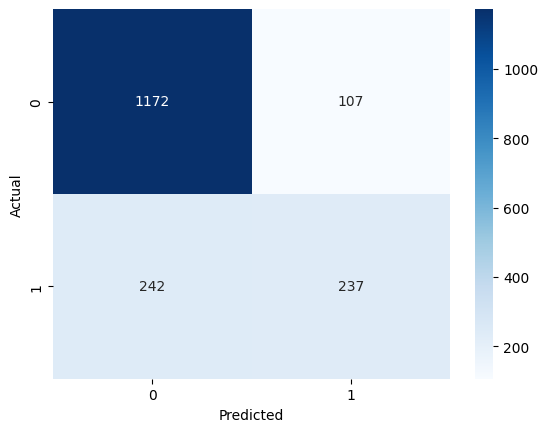

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Confusion matrix:")
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt="d",cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Exporting data
The original dataframe will be expanded with a few more columns using the model's predictions and exported to a csv file. This is the last stage of the coding aspect of the project.

In [22]:
export_df = df_original.loc[X_test.index].copy()
export_df["ActualChurn"] = y_test
export_df["ChurnProbability"] = y_prob[:,1]
export_df["ChurnPrediction"] = y_pred

export_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ActualChurn,ChurnProbability,ChurnPrediction
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes,1,0.655280,1
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No,0,0.106938,0
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,Two year,No,Mailed check,19.35,1031.7,No,0,0.038413,0
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,Month-to-month,No,Electronic check,76.35,76.35,Yes,1,0.772769,1
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No,0,0.047256,0


In [23]:
export_df.to_csv("Telco_Churn_BI.csv")
print("Data exported to Telco_Churn_BI.csv.")

Data exported to Telco_Churn_BI.csv.


The exported csv file contains both the predictions and the probabilies the model used in the background, as well as all the original information given from the source. In order to see and communicate the business takeaways better the file will be used in Power BI for visualization.